In [10]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
plt.style.use('seaborn-poster')

#filename and folder to plot
fname= "walking_1"
folder = "hw2data/train/"

vals = np.load(folder+fname+".npy")
xyz = np.reshape( vals[:,:], (38,3,-1) )


print(xyz.shape)

#define the root joint and scaling of the values
r = 1000
xroot, yroot, zroot = xyz[0,0,0], xyz[0,0,1], xyz[0,0,2]

#define the connections between the joints (skeleton) 
I = np.array(
        [1, 2, 3, 4, 5, 6, 1, 8, 9, 10, 11, 12, 1, 14, 15, 16, 17, 18, 19, 16, 21, 22, 23, 25, 26, 24, 28, 16, 30, 31,
         32, 33, 34, 35, 33, 37]) - 1
J = np.array(
        [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32,
         33, 34, 35, 36, 37, 38]) - 1


(38, 3, 100)


C:\Users\27963\AppData\Local\Temp\ipykernel_15812\1575671491.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-poster')


In [11]:
print(xyz)

[[[ 8.37469697e-02  7.62334839e-02  7.07266107e-02 ...  1.00912876e-01
    1.02659233e-01  1.07420832e-01]
  [ 1.14693083e-01  1.07635967e-01  1.01648435e-01 ...  8.63805339e-02
    8.92904028e-02  9.65156555e-02]
  [-2.18185282e+00 -2.17923594e+00 -2.17784309e+00 ... -2.40246296e+00
   -2.39796042e+00 -2.38923454e+00]]

 [[ 8.37469697e-02  7.62334839e-02  7.07266107e-02 ...  1.00912876e-01
    1.02659233e-01  1.07420832e-01]
  [ 1.14693083e-01  1.07635967e-01  1.01648435e-01 ...  8.63805339e-02
    8.92904028e-02  9.65156555e-02]
  [-2.18185282e+00 -2.17923594e+00 -2.17784309e+00 ... -2.40246296e+00
   -2.39796042e+00 -2.38923454e+00]]

 [[-2.39579605e+01 -2.39509213e+01 -2.40806438e+01 ... -5.20983351e+01
   -5.13956531e+01 -4.99500816e+01]
  [-1.06708405e+02 -1.07910365e+02 -1.08820620e+02 ... -9.76561310e+01
   -9.76035477e+01 -9.72650735e+01]
  [-1.41453154e+02 -1.40536014e+02 -1.39811552e+02 ... -1.40613173e+02
   -1.40913351e+02 -1.41671805e+02]]

 ...

 [[ 4.77746622e+02  4.765

In [12]:
X_train = np.load("hw2data/train/walking_1.npy")
for i in range(1, 15):
    fname= ["walking_1", "walking_2","walking_3","walking_4","walking_5","jumping_1", "jumping_2","jumping_3","jumping_4","jumping_5","running_1", "running_2","running_3","running_4","running_5"]
    folder = "hw2data/train/"

    vals = np.load(folder+fname[i]+".npy")
    X_train = np.hstack((X_train, vals))
    
X_train=np.array(X_train)
print(X_train.shape)

(114, 1500)


In [13]:
print(X_train)

[[ 8.37469697e-02  7.62334839e-02  7.07266107e-02 ...  1.52190700e-01
   1.69395506e-01  1.85640782e-01]
 [ 1.14693083e-01  1.07635967e-01  1.01648435e-01 ...  1.51954651e-01
   1.70147091e-01  1.87446848e-01]
 [-2.18185282e+00 -2.17923594e+00 -2.17784309e+00 ... -2.28637552e+00
  -2.28087354e+00 -2.27521682e+00]
 ...
 [ 4.30476387e+02  4.29316536e+02  4.29546498e+02 ...  3.13859956e+02
   3.19975256e+02  3.17101756e+02]
 [-1.62000436e+00 -2.39185355e+00 -3.42141797e+00 ... -5.52496886e+01
  -6.84019801e+01 -7.13617088e+01]
 [-1.49678823e+02 -1.51470563e+02 -1.52352970e+02 ...  2.79590353e+01
   4.37435490e+01  6.00343979e+01]]


In [14]:
mean_X_train = np.mean(X_train, axis=1, keepdims=True)
X_train_c = X_train - mean_X_train

print(f"X_train shape: {X_train.shape}")

X_train shape: (114, 1500)


In [15]:
print(X_train_c)

[[ 4.76282206e-02  4.01147348e-02  3.46078616e-02 ...  1.16071951e-01
   1.33276757e-01  1.49522033e-01]
 [ 8.55695521e-02  7.85124367e-02  7.25249042e-02 ...  1.22831120e-01
   1.41023560e-01  1.58323317e-01]
 [ 1.31444269e-01  1.34061152e-01  1.35453993e-01 ...  2.69215644e-02
   3.24235500e-02  3.80802692e-02]
 ...
 [ 1.78404663e+02  1.77244811e+02  1.77474773e+02 ...  6.17882319e+01
   6.79035318e+01  6.50300315e+01]
 [-1.12881298e+02 -1.13653147e+02 -1.14682712e+02 ... -1.66510982e+02
  -1.79663274e+02 -1.82623003e+02]
 [ 1.23213598e+01  1.05296199e+01  9.64721303e+00 ...  1.89959218e+02
   2.05743732e+02  2.22034581e+02]]


2 PCA spatial modes are needed to keep to approximate Xtrain up to70%
3 PCA spatial modes are needed to keep to approximate Xtrain up to80%
5 PCA spatial modes are needed to keep to approximate Xtrain up to90%
7 PCA spatial modes are needed to keep to approximate Xtrain up to95%


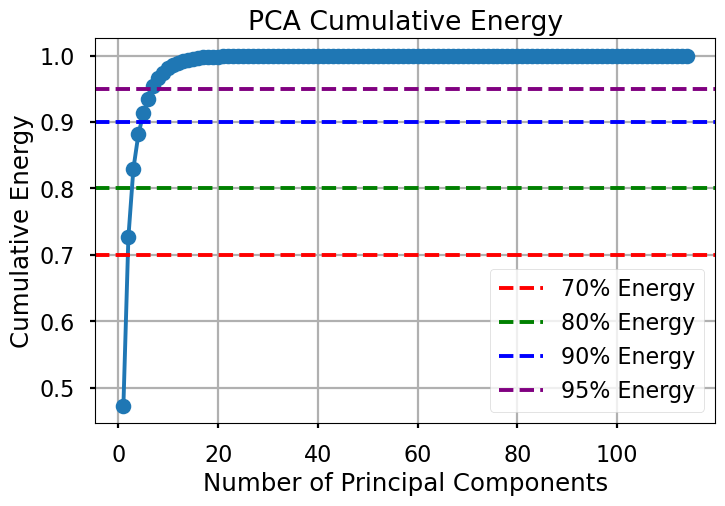

In [16]:
U, S, Vt = np.linalg.svd(X_train_c, full_matrices=False)
frobenius_total = np.linalg.norm(X_train_c, 'fro')**2
energy = np.cumsum(S**2) / frobenius_total

# look for modes needed in 70%、80%、90%、95% energy
thresholds = [0.7, 0.8, 0.9, 0.95]
k_values = [np.argmax(energy >= t) + 1 for t in thresholds]

for t, k in zip(thresholds, k_values):
    print(f"{k} PCA spatial modes are needed to keep to approximate Xtrain up to{int(t * 100)}%")


plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(S) + 1), energy, marker='o', linestyle='-')
plt.axhline(y=0.7, color='r', linestyle='--', label='70% Energy')
plt.axhline(y=0.8, color='g', linestyle='--', label='80% Energy')
plt.axhline(y=0.9, color='b', linestyle='--', label='90% Energy')
plt.axhline(y=0.95, color='purple', linestyle='--', label='95% Energy')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Energy")
plt.title("PCA Cumulative Energy")
plt.legend()
plt.grid()
plt.show()

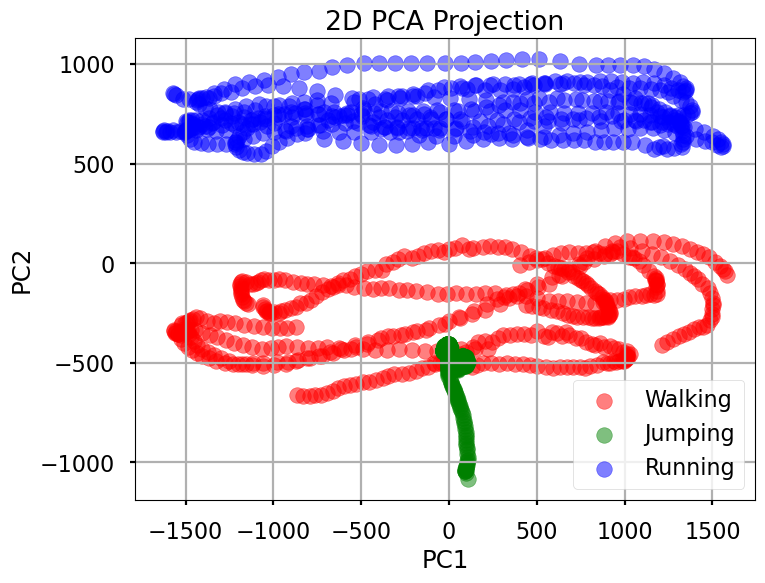

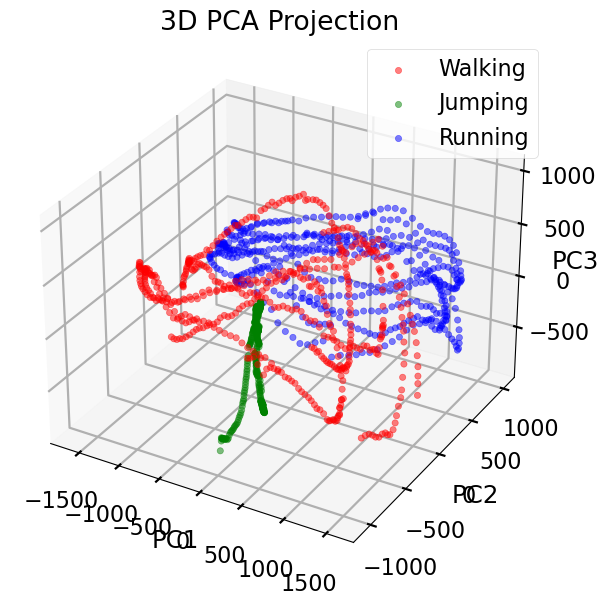

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# select first k=2 or 3 modes
k_2d, k_3d = 2, 3
X_pca_2d = U[:, :k_2d].T @ X_train_c  # (2, 1500)
X_pca_3d = U[:, :k_3d].T @ X_train_c  # (3, 1500)

# define the lable and color
colors = ['r', 'g', 'b']
labels = ["Walking", "Jumping", "Running"]

# plot 2D trajectories
plt.figure(figsize=(8, 6))
for i in range(3):  
    plt.scatter(X_pca_2d[0, i * 500:(i + 1) * 500], 
                X_pca_2d[1, i * 500:(i + 1) * 500], 
                c=colors[i], label=labels[i], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.legend()
plt.grid()
plt.show()

#  plot 3D trajectories
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for i in range(3):
    ax.scatter(X_pca_3d[0, i * 500:(i + 1) * 500], 
               X_pca_3d[1, i * 500:(i + 1) * 500], 
               X_pca_3d[2, i * 500:(i + 1) * 500], 
               c=colors[i], label=labels[i], alpha=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
ax.legend()
plt.show()

In [18]:
print(X_pca_2d.shape)

(2, 1500)


In [19]:
# Consider mode=3
k_pca = 3
X_train_pca = U[:, :k_pca].T @ X_train_c  # compute 3-PCA trajectories (3, 1500)

# generate Ground Truth lable
num_samples_per_class = 5 * 100 
y_train = np.array([0] * num_samples_per_class + 
                   [1] * num_samples_per_class + 
                   [2] * num_samples_per_class)  # 0: Walking, 1: Jumping, 2: Running

# look for the Centroid
centroids = []
for i in range(3):  # 3 classes
    class_data = X_train_pca[:, i * num_samples_per_class:(i + 1) * num_samples_per_class] 
    centroid = np.mean(class_data, axis=1) 
    centroids.append(centroid)

centroids = np.array(centroids)  # reshape to (3, k_pca) 


print("Centroids for each motion in 3-PCA space：")
for i, label in enumerate(["Walking", "Jumping", "Running"]):
    print(f"{label} Centroid: {centroids[i]}")

Centroids for each motion in 3-PCA space：
Walking Centroid: [  36.88211143 -253.35282541  175.91202104]
Jumping Centroid: [  23.88986635 -499.36826149  -72.5000755 ]
Running Centroid: [ -60.77197779  752.7210869  -103.41194553]


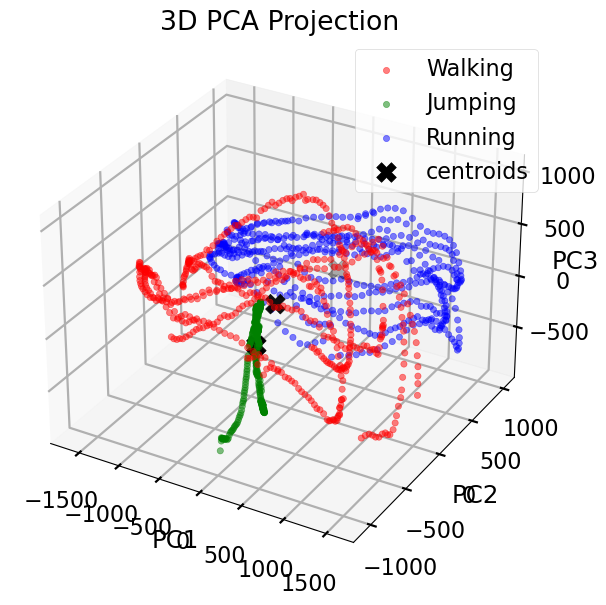

In [20]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for i in range(3):
    ax.scatter(X_train_pca[0, i * 500:(i + 1) * 500], 
               X_train_pca[1, i * 500:(i + 1) * 500], 
               X_train_pca[2, i * 500:(i + 1) * 500], 
               c=colors[i], label=labels[i], alpha=0.5)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
           c='black', marker='X', s=200, label='centroids')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
ax.legend()
plt.show()

In [21]:
print(y_train)

[0 0 0 ... 2 2 2]


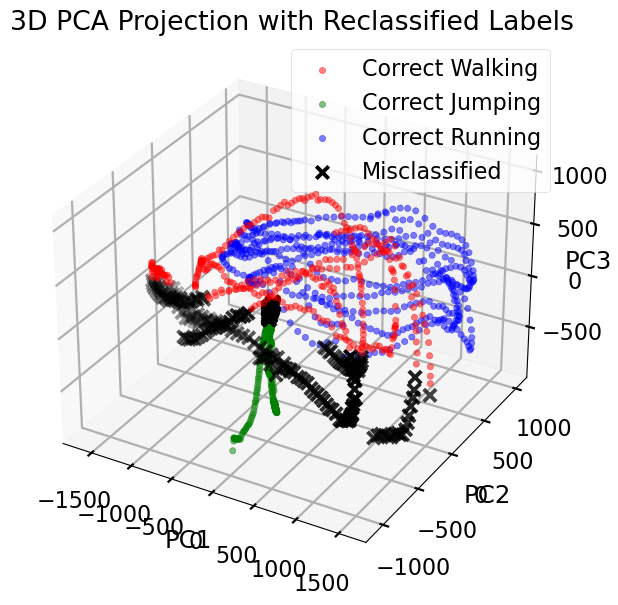

accuracy: 0.7560


In [22]:
from sklearn.metrics import accuracy_score
import numpy as np

# classify by the nearest centroids
y_train_pred = []
for j in range(X_train_pca.shape[1]):  #
    distances = np.linalg.norm(X_train_pca[:, j].reshape(-1, 1) - centroids.T, axis=0)  
    y_train_pred.append(np.argmin(distances)) 
y_train_pred = np.array(y_train_pred)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i in range(3):  # 遍历 3 种运动类别
    mask = (y_train == i) & (y_train_pred == i)  # 正确分类的点
    ax.scatter(X_train_pca[0, mask], X_train_pca[1, mask], X_train_pca[2, mask], 
               c=colors[i], label=f"Correct {labels[i]}", alpha=0.5)

# 绘制错误分类的点（用黑色边框）
wrong_mask = y_train != y_train_pred  # 错误分类的点
ax.scatter(X_train_pca[0, wrong_mask], X_train_pca[1, wrong_mask], X_train_pca[2, wrong_mask], 
           c='black', marker='x', s=80, label="Misclassified")

# 4. 设置坐标轴和标题
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection with Reclassified Labels")
ax.legend()
plt.show()
# compute the accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"accuracy: {train_accuracy:.4f}")


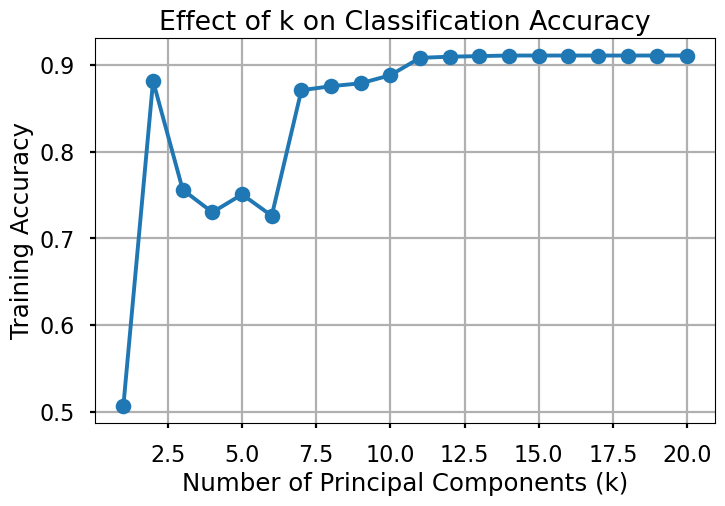

In [23]:
import matplotlib.pyplot as plt

# try for k = 1 - 20
k_values = list(range(1, 21)) 
train_accuracies = []

for k_pca in k_values:
    #  compute k-PCA trajectories
    X_train_pca_k = U[:, :k_pca].T @ X_train_c  # (k_pca, 1500)

    # look for the centroids
    centroids_k = []
    for i in range(3):  
        class_data_k = X_train_pca_k[:, i * num_samples_per_class:(i + 1) * num_samples_per_class]
        centroid_k = np.mean(class_data_k, axis=1)
        centroids_k.append(centroid_k)
    centroids_k = np.array(centroids_k)  # (3, k_pca)

    # classify by the nearest centroids
    y_train_pred_k = []
    for j in range(X_train_pca_k.shape[1]):
        distances_k = np.linalg.norm(X_train_pca_k[:, j].reshape(-1, 1) - centroids_k.T, axis=0)
        y_train_pred_k.append(np.argmin(distances_k))
    y_train_pred_k = np.array(y_train_pred_k)

    # compute the accuracy
    train_acc_k = accuracy_score(y_train, y_train_pred_k)
    train_accuracies.append(train_acc_k)

# plot the accuracy depend on k
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', linestyle='-')
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Training Accuracy")
plt.title("Effect of k on Classification Accuracy")
plt.grid()
plt.show()

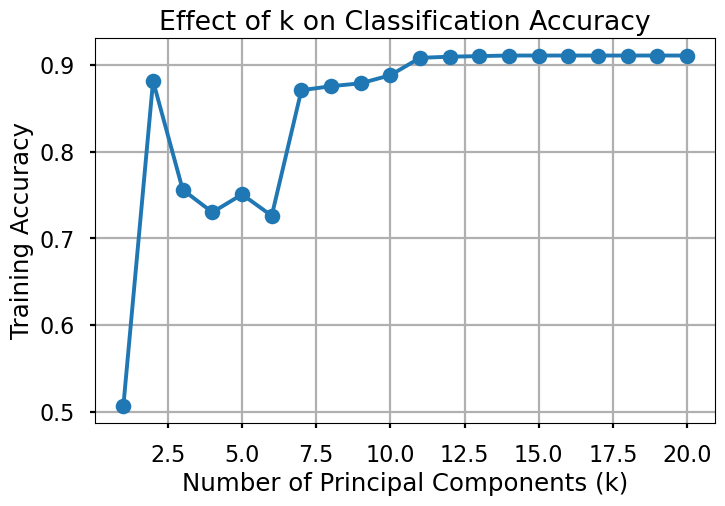

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# try for k = 1 - 20
k_values = list(range(1, 21))  
train_accuracies = []

for k_pca in k_values:
    #  compute k-PCA trajectories
    pca = PCA(n_components=k_pca)
    X_train_pca = pca.fit_transform(X_train_c.T)  # (1500, k_pca)，转置以符合 sklearn 习惯

    # look for the centroids
    centroids = []
    for i in range(3):  
        class_data = X_train_pca[i * num_samples_per_class:(i + 1) * num_samples_per_class]
        centroids.append(np.mean(class_data, axis=0))  
    centroids = np.array(centroids)  # (3, k_pca)

    # classify by the nearest centroids
    y_train_pred = []
    for sample in X_train_pca:
        distances = np.linalg.norm(sample - centroids, axis=1) 
        y_train_pred.append(np.argmin(distances)) 
    y_train_pred = np.array(y_train_pred)

    # compute the accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_accuracy)

# plot the accuracy depend on k
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', linestyle='-')
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Training Accuracy")
plt.title("Effect of k on Classification Accuracy")
plt.grid()
plt.show()

In [43]:
k_values = np.arange(1, len(train_accuracies) + 1)  


best_index = np.argmax(train_accuracies)  # 找到最大值的索引
best_k = k_values[best_index]  # 对应的 k 值
best_accuracy = train_accuracies[best_index]  # 最高准确率

print(f"optimal k: {best_k}, highest accuracy: {best_accuracy:.4f}")

optimal k: 14, highest accuracy: 0.9107


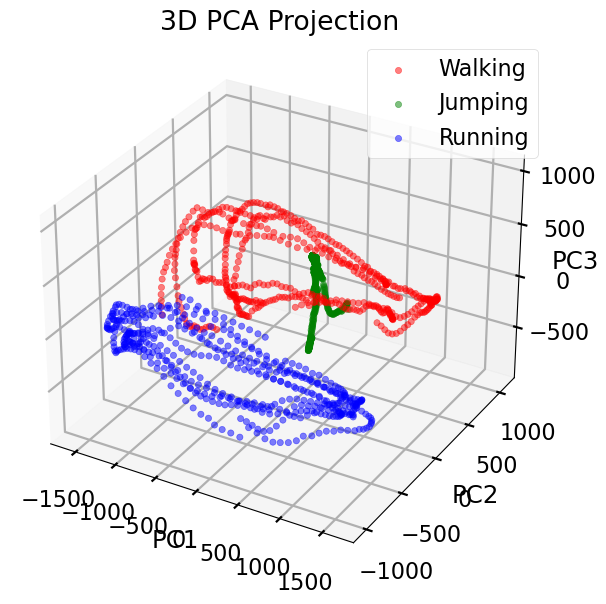

In [26]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_c.T)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for i in range(3):
    ax.scatter(X_train_pca.T[0, i * 500:(i + 1) * 500], 
               X_train_pca.T[1, i * 500:(i + 1) * 500], 
               X_train_pca.T[2, i * 500:(i + 1) * 500], 
               c=colors[i], label=labels[i], alpha=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
ax.legend()
plt.show()

In [27]:
print(X_train_pca.T)

[[1147.32795839 1157.72355109 1166.83750195 ...  170.30385482
   285.7165049   385.31884277]
 [ 205.67606278  197.23489654  190.22764673 ... -641.56278735
  -658.78102172 -673.2893723 ]
 [  45.31340306   48.28005423   51.38990606 ...  227.04839224
   226.56502827  227.06250186]]


In [28]:
print(X_pca_3d)

[[-1147.32795839 -1157.72355109 -1166.83750195 ...  -170.30385482
   -285.7165049   -385.31884277]
 [ -205.67606278  -197.23489654  -190.22764673 ...   641.56278735
    658.78102172   673.2893723 ]
 [   45.31340306    48.28005423    51.38990606 ...   227.04839224
    226.56502827   227.06250186]]


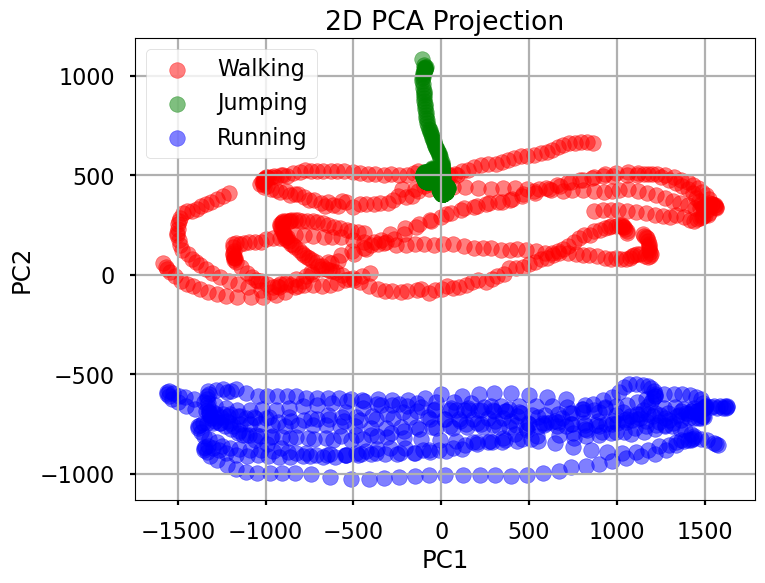

In [29]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_c.T)
plt.figure(figsize=(8, 6))
for i in range(3):  # 3 种运动类型
    plt.scatter(X_train_pca.T[0, i * 500:(i + 1) * 500], 
                X_train_pca.T[1, i * 500:(i + 1) * 500], 
                c=colors[i], label=labels[i], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.legend()
plt.grid()
plt.show()

In [33]:
X_test = np.load("hw2data/test/walking_1t.npy")
for i in range(1, 3):
    fname= ["walking_1t","jumping_1t","running_1t"]
    folder = "hw2data/test/"
    vals = np.load(folder+fname[i]+".npy")
    X_test = np.hstack((X_test, vals))
    
X_test=np.array(X_test)
print(X_test.shape)

(114, 300)


In [34]:
num_samples_per_class_test = 100 
y_test = np.array([0] * num_samples_per_class_test + 
                   [1] * num_samples_per_class_test + 
                   [2] * num_samples_per_class_test)  # 0: Walking, 1: Jumping, 2: Running
mean_X_test = np.mean(X_test, axis=1, keepdims=True)
X_test_c = X_test - mean_X_test

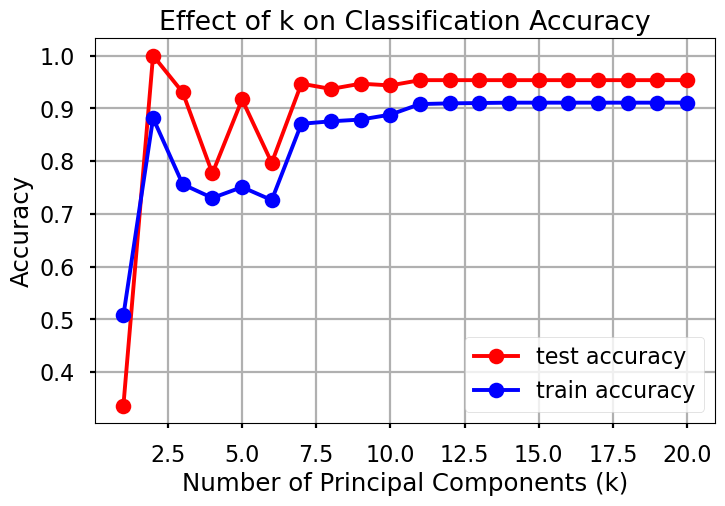

In [35]:
import matplotlib.pyplot as plt

# try for k = 1 ~ 20
k_values = list(range(1, 21)) 
test_accuracies = []

for k_pca in k_values:
    #  compute k-PCA trajectories
    X_train_pca_k = U[:, :k_pca].T @ X_train_c  # (k_pca, 1500)
    X_test_pca_k = U[:, :k_pca].T @ X_test_c

    # look for the centroids
    centroids_k = []
    for i in range(3):  
        class_data_k = X_train_pca_k[:, i * num_samples_per_class:(i + 1) * num_samples_per_class]
        centroid_k = np.mean(class_data_k, axis=1)
        centroids_k.append(centroid_k)
    centroids_k = np.array(centroids_k)  # (3, k_pca)

    # classify by the nearest centroids
    y_test_pred_k = []
    for j in range(X_test_pca_k.shape[1]):
        distances_k = np.linalg.norm(X_test_pca_k[:, j].reshape(-1, 1) - centroids_k.T, axis=0)
        y_test_pred_k.append(np.argmin(distances_k))
    y_test_pred_k = np.array(y_test_pred_k)

    # compute the accuracy
    test_acc_k = accuracy_score(y_test, y_test_pred_k)
    test_accuracies.append(test_acc_k)

# plot the accuracy depend on k
plt.figure(figsize=(8, 5))
plt.plot(k_values, test_accuracies, c='r', marker='o', linestyle='-',  label = "test accuracy")
plt.plot(k_values, train_accuracies, c='b', marker='o', linestyle='-',  label = "train accuracy")
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Accuracy")
plt.title("Effect of k on Classification Accuracy")
plt.legend()
plt.grid()
plt.show()

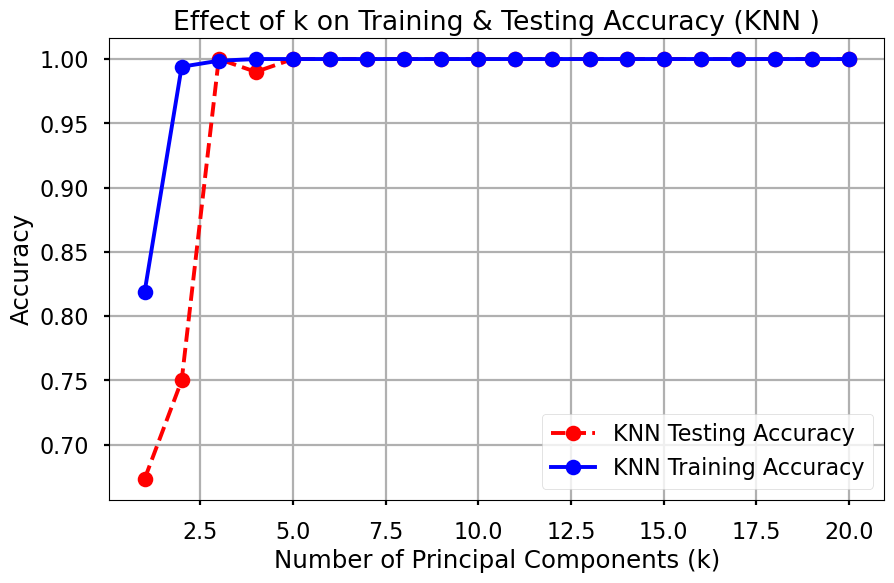

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# try for k = 1 ~ 20
k_values = list(range(1, 21))  
train_accuracies_knn = []
test_accuracies_knn = []

for k_pca in k_values:
    #  compute k-PCA trajectories
    pca = PCA(n_components=k_pca)
    X_train_pca = pca.fit_transform(X_train_c.T)  #  (1500, k_pca)
    X_test_pca = pca.transform(X_test_c.T)  #  (300, k_pca)

    #  KNN method
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_pca, y_train)
    y_train_pred_knn = knn.predict(X_train_pca)
    y_test_pred_knn = knn.predict(X_test_pca)



    # 4. 计算分类准确率
    train_accuracies_knn.append(accuracy_score(y_train, y_train_pred_knn))
    test_accuracies_knn.append(accuracy_score(y_test, y_test_pred_knn))


# 5. 绘制准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(k_values, test_accuracies_knn, 'ro--', label="KNN Testing Accuracy")
plt.plot(k_values, train_accuracies_knn, 'bo-', label="KNN Training Accuracy")

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Accuracy")
plt.title("Effect of k on Training & Testing Accuracy (KNN )")
plt.legend()
plt.grid()
plt.show()